## Pennsylvania - 2 pfts 

#### Libraries

In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

#### Load the FATES runs  
- note we did this in four cases each with 250 members

In [3]:
fates1='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_1.Ef14a3cf738-Fb8e4eee5.2024-12-06/run/PA_ensemble_1.Ef14a3cf738-Fb8e4eee5.2024-12-06.h0.ensemble.sofar.nc'
fates1 = xr.open_dataset(fates1,  decode_times=False)

fates2='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ensemble_2.Ef14a3cf738-Fb8e4eee5.2024-12-06/run/PA_ensemble_2.Ef14a3cf738-Fb8e4eee5.2024-12-06.h0.ensemble.sofar.nc'
fates2 = xr.open_dataset(fates2,  decode_times=False)

fates = xr.concat([fates1, fates2], dim='record')

In [37]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

print(tave_start)
print(tave_stop)

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

n_lon = len(fates.variables['lon'])
ninst = n_lon
print(ninst)

300
3360
3600
500


### Veg C through time 

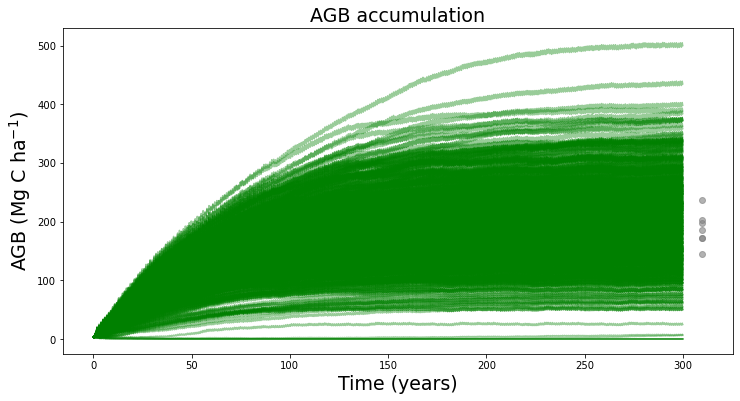

In [5]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

for  i in range(0,ninst):
    if i == 0: 
        f1ax0.plot(time, AGB[i], color='green', label = 'FATES', alpha = 0.4)    
    else: 
        f1ax0.plot(time, AGB[i,:], color='green', alpha = 0.4)

f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
;

gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16]

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

In [6]:
print(np.mean(gedi_y))

187.32


### How many ensemble members have coexistence 

In [7]:
vegc = fates.FATES_VEGC_PF

coex = []
vegc1_frac = []
vegc2_frac = []


vegc1 = []
vegc2 = []
vegctotal = []

for i in range(0,ninst):
    veg =  vegc.isel(record=i)
    # percent total  biomass of each tree PFT
    vegcfinal = veg.isel(time=3599)
    total = vegcfinal.sum(dim=('fates_levpft'))
    pft1 = (vegcfinal.isel(fates_levpft=0)  / total ).values
    pft2 = (vegcfinal.isel(fates_levpft=1)  / total ).values
    
    vegc1_frac.append(pft1)
    vegc2_frac.append(pft2)
    
    vegc1.append(vegcfinal.isel(fates_levpft=0).values)
    vegc2.append(vegcfinal.isel(fates_levpft=1).values)
    
    vegctotal.append(total)
                 
     # make sure no PFT has more than 90% of biomass 
    if (pft1 < 0.8 and pft2 < 0.8 ) :
        coex.append(i)
    
        
print(len(coex))   

48


''

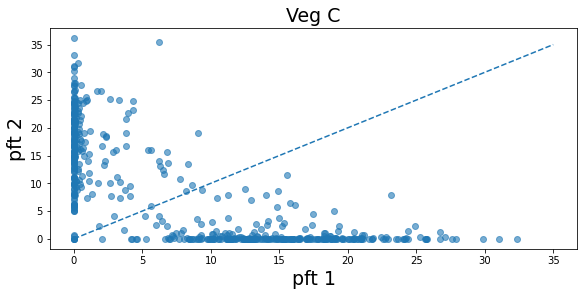

In [8]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(8,4), constrained_layout=True)


f1ax0.scatter(vegc1, vegc2, alpha = 0.6)
f1ax0.set_title(r'Veg C', fontsize = 19)
f1ax0.set_xlabel(r'pft 1', fontsize = 19)
f1ax0.set_ylabel(r'pft 2', fontsize = 19)

f1ax0.plot(np.linspace(0,35,36), np.linspace(0,35,36),  linestyle='--')
;

### Disturb frac v pft 1 

In [9]:
sampledf = pd.read_csv('/global/homes/j/jneedham/FATES-MRV/param_files/2pft_samples.csv')

In [10]:
sampledf.head(3)

,fates_maintresp_nonleaf_baserate0,fates_mort_understorey_death0,fates_mort_disturb_frac0,fates_maintresp_leaf_vert_scaler_coeff22,fates_maintresp_leaf_vert_scaler_coeff21,fates_maintresp_leaf_atkin2017_baserate2,fates_maintresp_leaf_atkin2017_baserate1,fates_leaf_slatop2,fates_leaf_slatop1,fates_alloc_storage_cushion2,...,fates_mort_scalar_cstarvation2,fates_mort_scalar_cstarvation1,fates_recruit_seed_alloc2,fates_recruit_seed_alloc1,fates_recruit_seed_dbh_repro_threshold2,fates_recruit_seed_dbh_repro_threshold1,fates_turnover_branch2,fates_turnover_branch1,fates_leaf_vcmax25top2,fates_leaf_vcmax25top1
0,0.000003,0.693431,0.780298,2.343228,2.349946,1.552130,1.689458,0.026853,0.030081,2.990909,...,0.469628,0.671563,0.086107,0.090005,86.246173,63.535929,163.020428,149.207640,58.261354,73.285899
1,0.000002,0.187836,0.660265,1.897793,2.400569,1.860247,2.155432,0.033526,0.035000,2.572089,...,0.522481,0.551242,0.076620,0.077076,72.575646,63.802508,166.777793,152.354174,62.632826,83.017856
2,0.000003,0.460757,0.382761,1.981509,2.409116,2.084878,2.107087,0.035692,0.035839,2.538974,...,0.585469,0.603884,0.110253,0.112606,63.866103,40.479699,184.222743,80.388204,66.043996,66.845911


### Ecosystem parameters

Text(0, 0.5, 'Total Veg C')

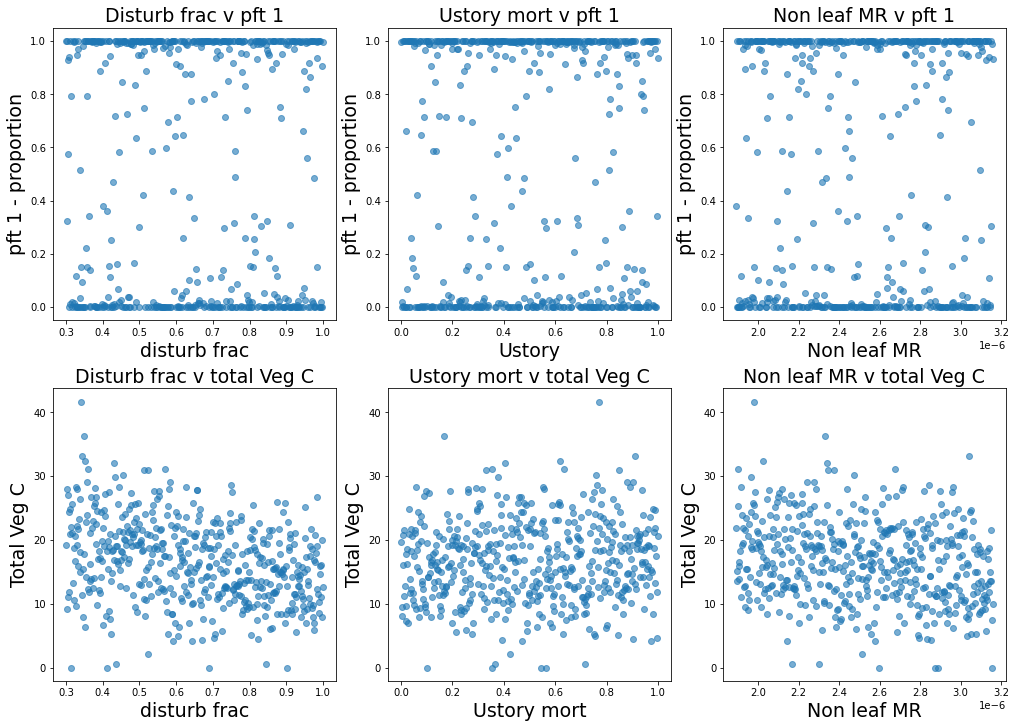

In [11]:
fig1, ((f1ax0, f1ax1, f1ax2), (f1ax3, f1ax4, f1ax5)) = plt.subplots(nrows=2,ncols=3, figsize=(14,10), 
                                                                                           constrained_layout=True)


f1ax0.scatter(sampledf['fates_mort_disturb_frac0'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'Disturb frac v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'disturb frac', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_mort_disturb_frac0'], vegctotal, alpha = 0.6)
f1ax3.set_title(r'Disturb frac v total Veg C', fontsize = 19)
f1ax3.set_xlabel(r'disturb frac', fontsize = 19)
f1ax3.set_ylabel(r'Total Veg C', fontsize = 19)


f1ax1.scatter(sampledf['fates_mort_understorey_death0'], vegc1_frac, alpha = 0.6)
f1ax1.set_title(r'Ustory mort v pft 1', fontsize = 19)
f1ax1.set_xlabel(r'Ustory', fontsize = 19)
f1ax1.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax4.scatter(sampledf['fates_mort_understorey_death0'], vegctotal, alpha = 0.6)
f1ax4.set_title(r'Ustory mort v total Veg C', fontsize = 19)
f1ax4.set_xlabel(r'Ustory mort', fontsize = 19)
f1ax4.set_ylabel(r'Total Veg C', fontsize = 19)


f1ax2.scatter(sampledf['fates_maintresp_nonleaf_baserate0'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'Non leaf MR v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'Non leaf MR', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax5.scatter(sampledf['fates_maintresp_nonleaf_baserate0'], vegctotal, alpha = 0.6)
f1ax5.set_title(r'Non leaf MR v total Veg C', fontsize = 19)
f1ax5.set_xlabel(r'Non leaf MR', fontsize = 19)
f1ax5.set_ylabel(r'Total Veg C', fontsize = 19)



### Vcmax and SLA

Text(0, 0.5, 'pft 2 - proportion')

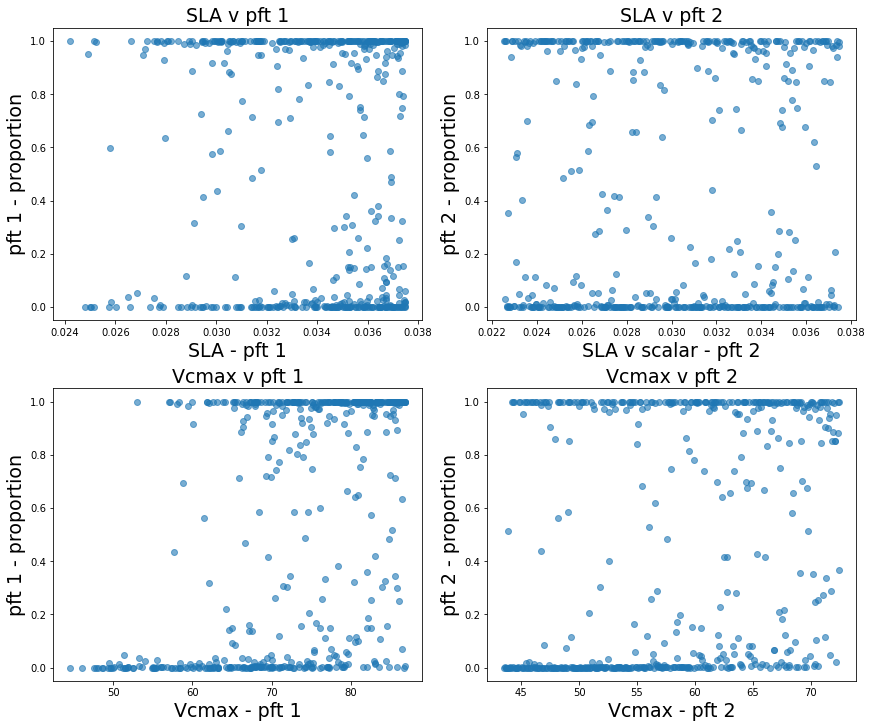

In [12]:
fig1, ((f1ax0,f1ax1),(f1ax2,f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(12,10), constrained_layout=True)


f1ax0.scatter(sampledf['fates_leaf_slatop1'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'SLA v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'SLA - pft 1', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax1.scatter(sampledf['fates_leaf_slatop2'], vegc2_frac, alpha = 0.6)
f1ax1.set_title(r'SLA v pft 2', fontsize = 19)
f1ax1.set_xlabel(r'SLA v scalar - pft 2', fontsize = 19)
f1ax1.set_ylabel(r'pft 2 - proportion', fontsize = 19)

f1ax2.scatter(sampledf['fates_leaf_vcmax25top1'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'Vcmax v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'Vcmax - pft 1', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_leaf_vcmax25top2'], vegc2_frac, alpha = 0.6)
f1ax3.set_title(r'Vcmax v pft 2', fontsize = 19)
f1ax3.set_xlabel(r'Vcmax - pft 2', fontsize = 19)
f1ax3.set_ylabel(r'pft 2 - proportion', fontsize = 19)

### Mortality params

Text(0, 0.5, 'pft 2 - proportion')

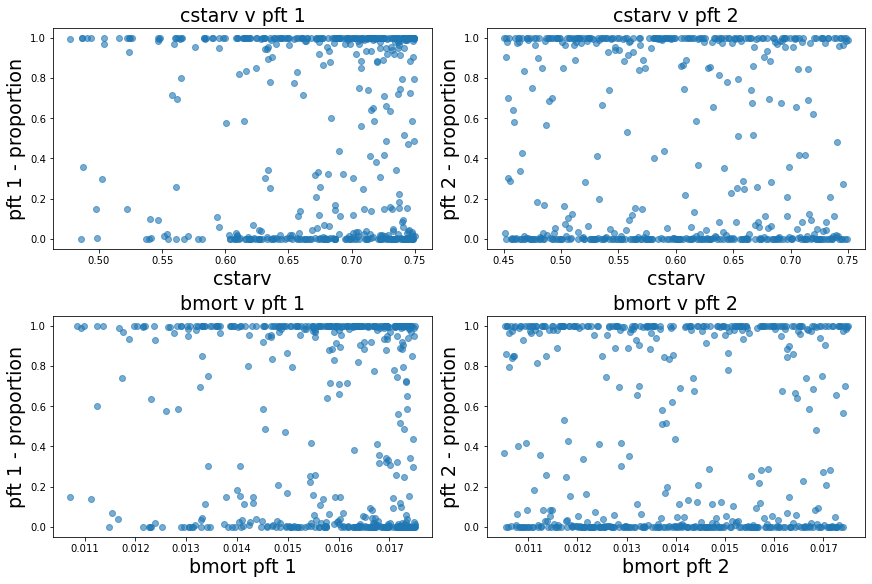

In [13]:
fig1, ((f1ax0, f1ax1), (f1ax2, f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(12,8), constrained_layout=True)


f1ax0.scatter(sampledf['fates_mort_scalar_cstarvation1'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'cstarv v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'cstarv', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax1.scatter(sampledf['fates_mort_scalar_cstarvation2'], vegc2_frac, alpha = 0.6)
f1ax1.set_title(r'cstarv v pft 2', fontsize = 19)
f1ax1.set_xlabel(r'cstarv', fontsize = 19)
f1ax1.set_ylabel(r'pft 2 - proportion', fontsize = 19)

f1ax2.scatter(sampledf['fates_mort_bmort1'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'bmort v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'bmort pft 1', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_mort_bmort2'], vegc2_frac, alpha = 0.6)
f1ax3.set_title(r'bmort v pft 2', fontsize = 19)
f1ax3.set_xlabel(r'bmort pft 2', fontsize = 19)
f1ax3.set_ylabel(r'pft 2 - proportion', fontsize = 19)


### Respiration params

Text(0, 0.5, 'pft 2 - proportion')

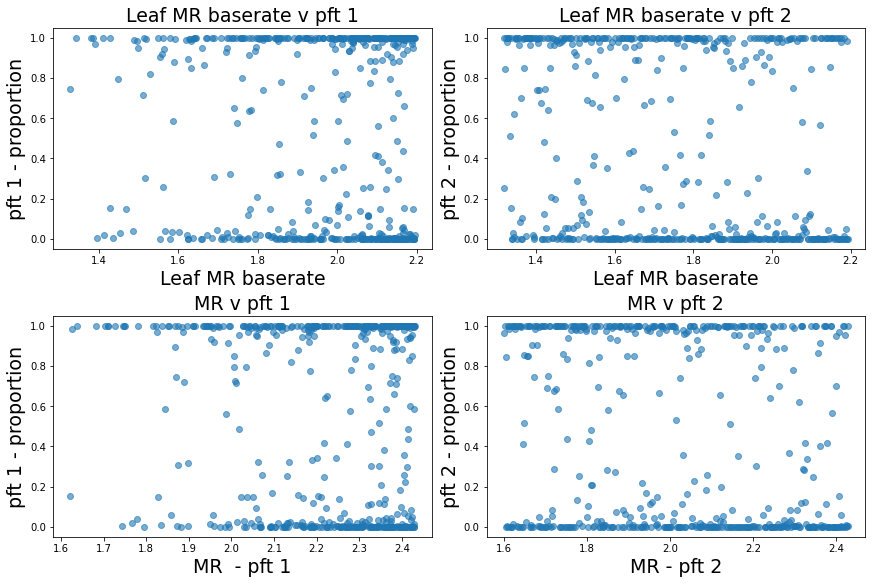

In [14]:
fig1, ((f1ax0, f1ax1), (f1ax2, f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(12,8), constrained_layout=True)


f1ax0.scatter(sampledf['fates_maintresp_leaf_atkin2017_baserate1'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'Leaf MR baserate v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'Leaf MR baserate', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax1.scatter(sampledf['fates_maintresp_leaf_atkin2017_baserate2'], vegc2_frac, alpha = 0.6)
f1ax1.set_title(r'Leaf MR baserate v pft 2', fontsize = 19)
f1ax1.set_xlabel(r'Leaf MR baserate', fontsize = 19)
f1ax1.set_ylabel(r'pft 2 - proportion', fontsize = 19)

f1ax2.scatter(sampledf['fates_maintresp_leaf_vert_scaler_coeff21'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'MR v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'MR  - pft 1', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_maintresp_leaf_vert_scaler_coeff22'], vegc2_frac, alpha = 0.6)
f1ax3.set_title(r'MR v pft 2', fontsize = 19)
f1ax3.set_xlabel(r'MR - pft 2', fontsize = 19)
f1ax3.set_ylabel(r'pft 2 - proportion', fontsize = 19)


### Storage and turnover

Text(0, 0.5, 'pft 2 - proportion')

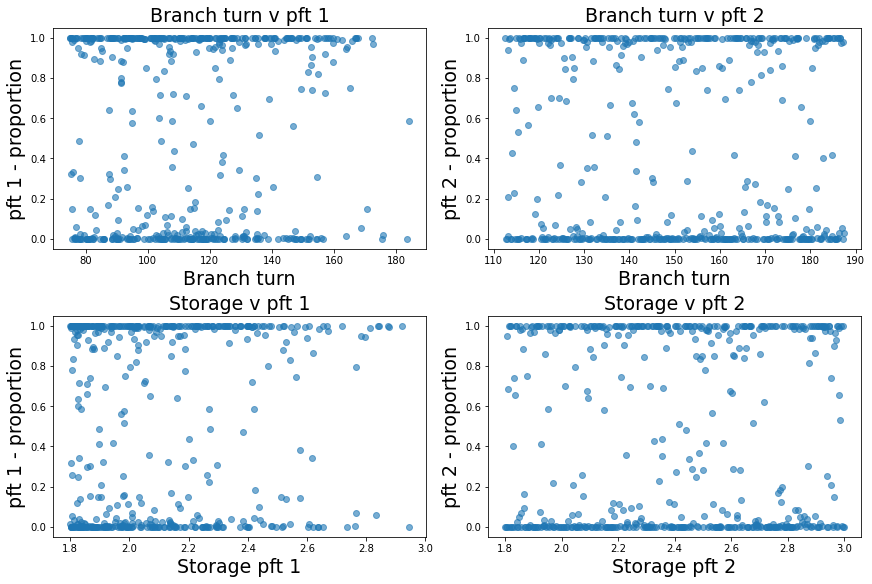

In [15]:
fig1, ((f1ax0, f1ax1), (f1ax2, f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(12,8), constrained_layout=True)


f1ax0.scatter(sampledf['fates_turnover_branch1'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'Branch turn v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'Branch turn', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax1.scatter(sampledf['fates_turnover_branch2'], vegc2_frac, alpha = 0.6)
f1ax1.set_title(r'Branch turn v pft 2', fontsize = 19)
f1ax1.set_xlabel(r'Branch turn', fontsize = 19)
f1ax1.set_ylabel(r'pft 2 - proportion', fontsize = 19)

f1ax2.scatter(sampledf['fates_alloc_storage_cushion1'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'Storage v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'Storage pft 1', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_alloc_storage_cushion2'], vegc2_frac, alpha = 0.6)
f1ax3.set_title(r'Storage v pft 2', fontsize = 19)
f1ax3.set_xlabel(r'Storage pft 2', fontsize = 19)
f1ax3.set_ylabel(r'pft 2 - proportion', fontsize = 19)


### Recruits 

Text(0, 0.5, 'pft 2 - proportion')

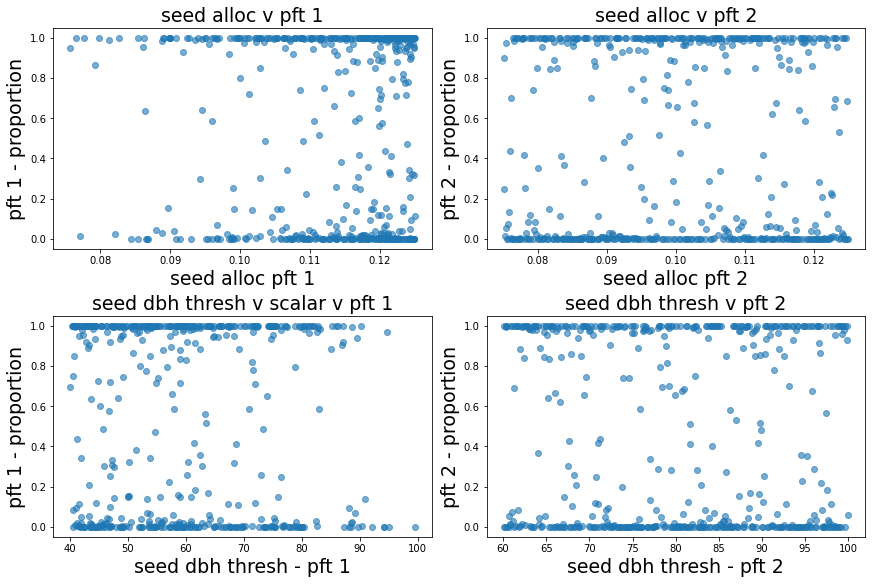

In [16]:
fig1, ((f1ax0, f1ax1), (f1ax2, f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(12,8), constrained_layout=True)


f1ax0.scatter(sampledf['fates_recruit_seed_alloc1'], vegc1_frac, alpha = 0.6)
f1ax0.set_title(r'seed alloc v pft 1', fontsize = 19)
f1ax0.set_xlabel(r'seed alloc pft 1', fontsize = 19)
f1ax0.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax1.scatter(sampledf['fates_recruit_seed_alloc2'], vegc2_frac, alpha = 0.6)
f1ax1.set_title(r'seed alloc v pft 2', fontsize = 19)
f1ax1.set_xlabel(r'seed alloc pft 2', fontsize = 19)
f1ax1.set_ylabel(r'pft 2 - proportion', fontsize = 19)

f1ax2.scatter(sampledf['fates_recruit_seed_dbh_repro_threshold1'], vegc1_frac, alpha = 0.6)
f1ax2.set_title(r'seed dbh thresh v scalar v pft 1', fontsize = 19)
f1ax2.set_xlabel(r'seed dbh thresh - pft 1', fontsize = 19)
f1ax2.set_ylabel(r'pft 1 - proportion', fontsize = 19)

f1ax3.scatter(sampledf['fates_recruit_seed_dbh_repro_threshold2'], vegc2_frac, alpha = 0.6)
f1ax3.set_title(r'seed dbh thresh v pft 2', fontsize = 19)
f1ax3.set_xlabel(r'seed dbh thresh - pft 2', fontsize = 19)
f1ax3.set_ylabel(r'pft 2 - proportion', fontsize = 19)


### Scatter plots pft 1 v pft 2 values - colour coded by dominance 

Text(0.02, 0.5, 'PFT 2')

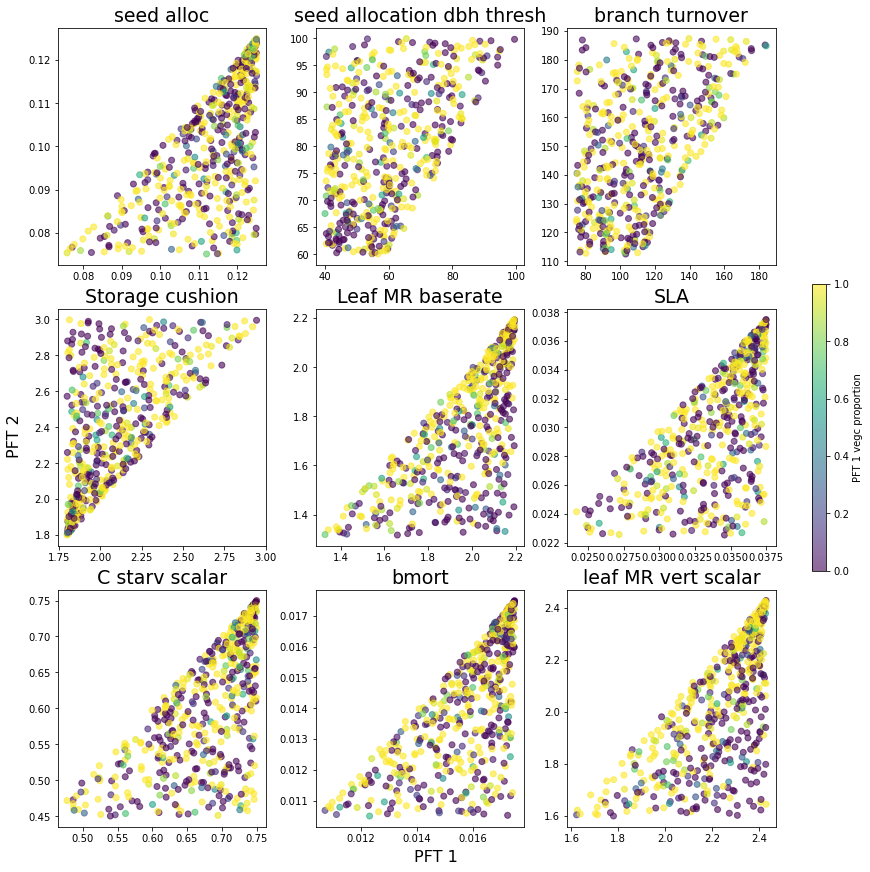

In [17]:
fig1, axes = plt.subplots(nrows=3,ncols=3, figsize=(12,12), constrained_layout=True)

axes[0,0].scatter(sampledf['fates_recruit_seed_alloc1'], sampledf['fates_recruit_seed_alloc2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[0,0].set_title(r'seed alloc', fontsize = 19)

axes[0,1].scatter(sampledf['fates_recruit_seed_dbh_repro_threshold1'], sampledf['fates_recruit_seed_dbh_repro_threshold2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[0,1].set_title(r'seed allocation dbh thresh', fontsize = 19)

axes[0,2].scatter(sampledf['fates_turnover_branch1'], sampledf['fates_turnover_branch2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[0,2].set_title(r'branch turnover', fontsize = 19)

axes[1,0].scatter(sampledf['fates_alloc_storage_cushion1'], sampledf['fates_alloc_storage_cushion2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[1,0].set_title(r'Storage cushion', fontsize = 19)

axes[1,1].scatter(sampledf['fates_maintresp_leaf_atkin2017_baserate1'], sampledf['fates_maintresp_leaf_atkin2017_baserate2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[1,1].set_title(r'Leaf MR baserate', fontsize = 19)

axes[1,2].scatter(sampledf['fates_leaf_slatop1'], sampledf['fates_leaf_slatop2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[1,2].set_title(r'SLA', fontsize = 19)

axes[2,0].scatter(sampledf['fates_mort_scalar_cstarvation1'], sampledf['fates_mort_scalar_cstarvation2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[2,0].set_title(r'C starv scalar', fontsize = 19)

axes[2,1].scatter(sampledf['fates_mort_bmort1'], sampledf['fates_mort_bmort2'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[2,1].set_title(r'bmort', fontsize = 19)

scat = axes[2,2].scatter(sampledf['fates_maintresp_leaf_vert_scaler_coeff21'], sampledf['fates_maintresp_leaf_vert_scaler_coeff22'], 
              alpha = 0.6, c=vegc1_frac, cmap='viridis')
axes[2,2].set_title(r'leaf MR vert scalar', fontsize = 19)

cbar = fig1.colorbar(scat, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('PFT 1 vegc proportion') 


fig1.supxlabel(r'PFT 1', fontsize=16)
fig1.supylabel(r'PFT 2', fontsize=16)



### Which ensemble members have high coexistence PFT 1 and PFT 2
No pft  with more than 80% of  biomass

In [18]:
vegc2_prop = np.concatenate(vegc2_frac).tolist()
vegc1_prop = np.concatenate(vegc1_frac).tolist()

In [19]:
indices = [i for i, value in enumerate(vegc1_prop) if value > 0.2 and value < 0.8]

print(len(indices))

48


(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

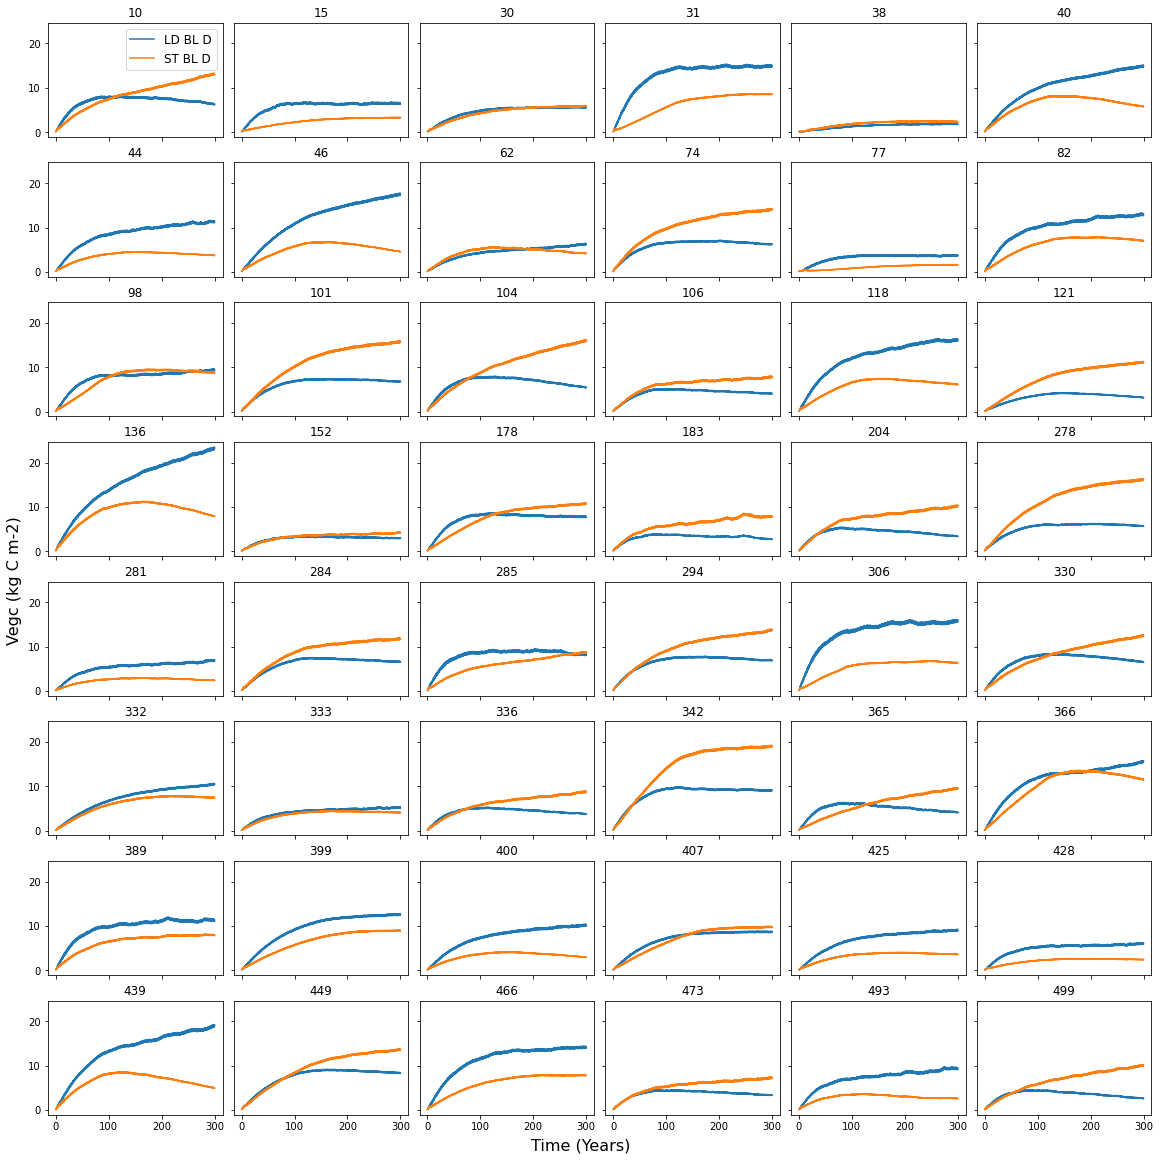

In [20]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=8,ncols=6, figsize=(16,16), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(indices)):
    axs[i].plot(time, AGB[indices[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[indices[i],:,1], label = 'ST BL D')      
    axs[i].set_title(indices[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

        

### Ensemble members within 10% of GEDI  mean

In [21]:
gedi_mean = np.mean(gedi_y)
print(gedi_mean)

187.32


In [22]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
print(AGB.shape)
AGB_tend = np.squeeze(AGB.isel(time=slice(3000,3600)).mean(dim='time'))
print(AGB_tend.shape)

(500, 3600, 1)
(500,)


In [23]:
indices_gedi = [i for i, value in enumerate(AGB_tend) if value > gedi_mean * 0.9 and value < gedi_mean*1.1]

print(len(indices_gedi))

85


(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

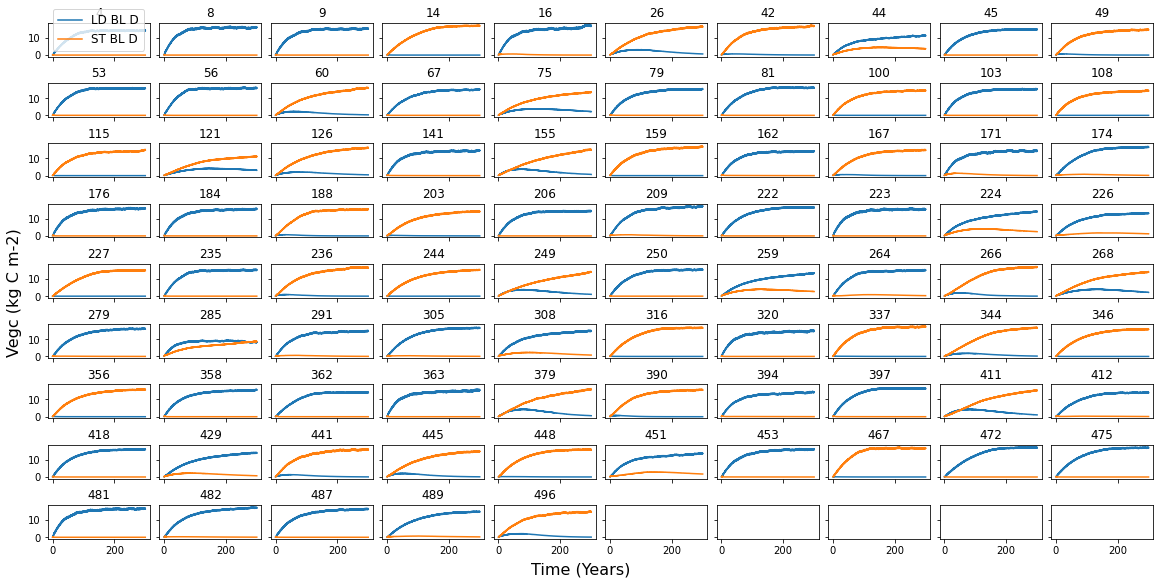

In [24]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=9,ncols=10, figsize=(16,8), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(indices_gedi)):
    axs[i].plot(time, AGB[indices_gedi[i],:,0],label = 'LD BL D')  
    axs[i].plot(time, AGB[indices_gedi[i],:,1], label = 'ST BL D')      
    axs[i].set_title(indices_gedi[i])
    if i == 0:
        axs[i].legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=16)

        

### best looking successional dynamics

(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

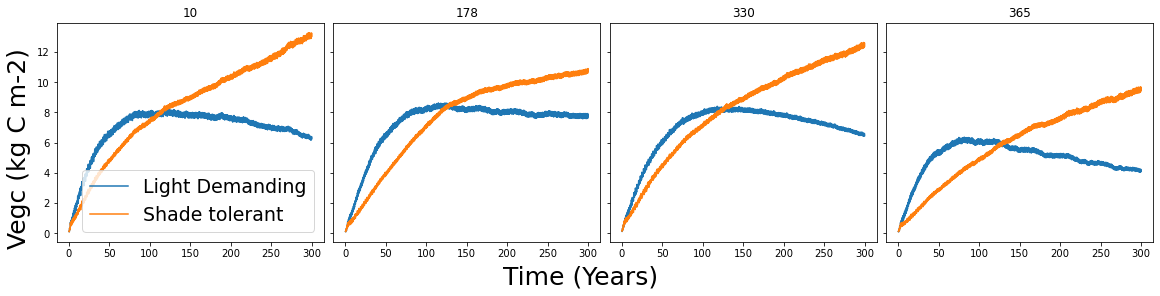

In [25]:
coex = [10,178,330,365]


AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=1,ncols=4, figsize=(16,4), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(coex)):
    axs[i].plot(time, AGB[coex[i],:,0],label = 'Light Demanding')  
    axs[i].plot(time, AGB[coex[i],:,1], label = 'Shade tolerant')      
    axs[i].set_title(coex[i])
    if i == 0:
        axs[i].legend(prop={'size':19})

fig1.supxlabel(r'Time (Years)', fontsize=25)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=25)

        

### But  they have too high biomass

In [26]:
AGB = fates.FATES_VEGC_PF
print(AGB.dims)

('record', 'time', 'fates_levpft', 'lndgrid')


(4, 3600, 1)


Text(0.02, 0.5, 'Vegc (Mg ha-1)')

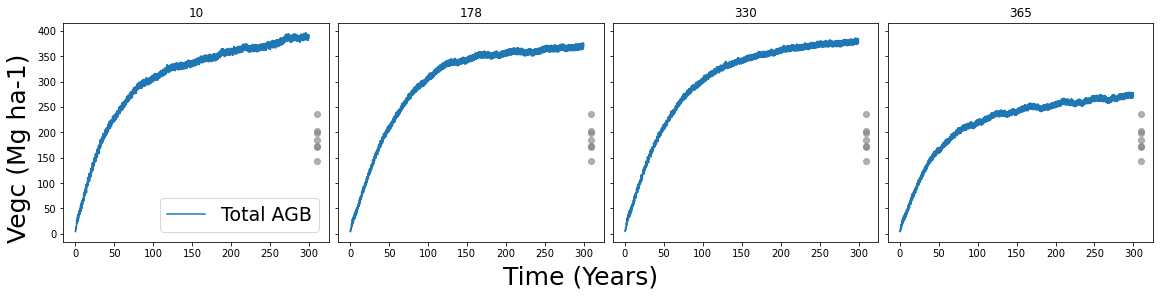

In [27]:
coex = [10,178,330,365]
gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16]



AGB = fates.FATES_VEGC_PF 
AGB_coex = AGB.sel(record = coex)
AGB_coex = AGB_coex.sum(dim='fates_levpft') * 10000 * 0.001 * 2 

print(AGB_coex.shape)

fig1, axs = plt.subplots(nrows=1,ncols=4, figsize=(16,4), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(coex)):
    axs[i].plot(time, AGB_coex.sel(record=i),label = 'Total AGB')       
    axs[i].set_title(coex[i])
    axs[i].scatter(gedi_x, gedi_y, alpha=0.6, color='grey')
    if i == 0:
        axs[i].legend(prop={'size':19})

fig1.supxlabel(r'Time (Years)', fontsize=25)
fig1.supylabel(r'Vegc (Mg ha-1)', fontsize=25)




###  Ensemble members  with coexistence and reasonable biomass

In [28]:
#print(indices)
#print(indices_gedi)
overlap = list(set(indices) & set(indices_gedi))
print(overlap)

[121, 44, 285]


(500, 3600, 2, 1)


Text(0.02, 0.5, 'Vegc (kg C m-2)')

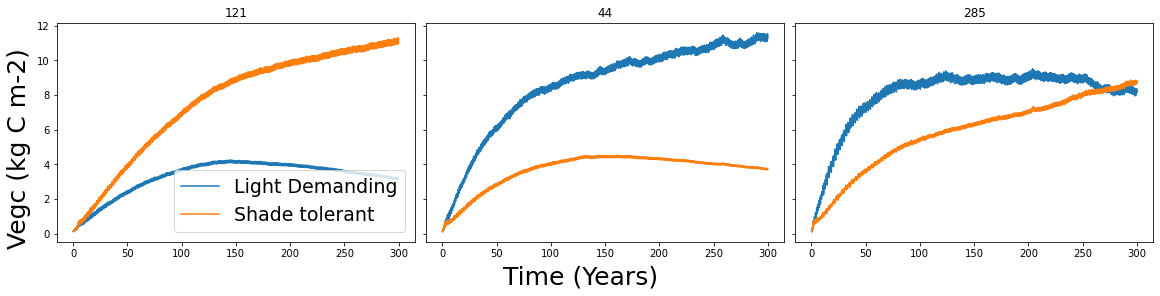

In [29]:
AGB = fates.FATES_VEGC_PF

print(AGB.shape)

fig1, axs = plt.subplots(nrows=1,ncols=3, figsize=(16,4), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(overlap)):
    axs[i].plot(time, AGB[overlap[i],:,0],label = 'Light Demanding')  
    axs[i].plot(time, AGB[overlap[i],:,1], label = 'Shade tolerant')      
    axs[i].set_title(overlap[i])
    if i == 0:
        axs[i].legend(prop={'size':19})

fig1.supxlabel(r'Time (Years)', fontsize=25)
fig1.supylabel(r'Vegc (kg C m-2)', fontsize=25)


(3, 3600, 1)


Text(0.02, 0.5, 'Vegc (Mg ha-1)')

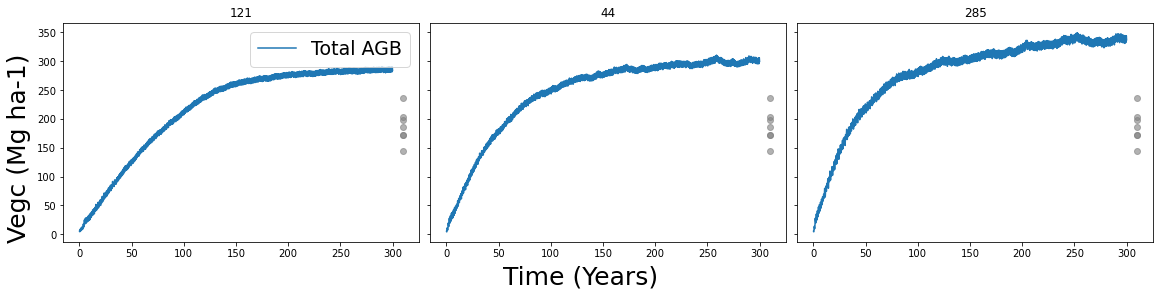

In [30]:
gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16]



AGB = fates.FATES_VEGC_PF 
AGB_coex = AGB.sel(record = overlap)
AGB_coex = AGB_coex.sum(dim='fates_levpft') * 10000 * 0.001 * 2 

print(AGB_coex.shape)

fig1, axs = plt.subplots(nrows=1,ncols=3, figsize=(16,4), constrained_layout=True, sharex=True, sharey=True)
axs=axs.flatten()

for  i in range(0,len(overlap)):
    axs[i].plot(time, AGB_coex.sel(record=i),label = 'Total AGB')       
    axs[i].set_title(overlap[i])
    axs[i].scatter(gedi_x, gedi_y, alpha=0.6, color='grey')
    if i == 0:
        axs[i].legend(prop={'size':19})

fig1.supxlabel(r'Time (Years)', fontsize=25)
fig1.supylabel(r'Vegc (Mg ha-1)', fontsize=25)


### quick test of best simulation

In [34]:
fates_v1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_best_run_test.Ef14a3cf738-Fb8e4eee5.2025-03-13/run/PA_best_run_test.Ef14a3cf738-Fb8e4eee5.2025-03-13.sofar.nc'
fates_v1 = xr.open_dataset(fates_v1, decode_times=False)

In [45]:
fates_best = fates.isel(record=365)

In [38]:
nyears = int(len(fates_v1.variables['time'])/12)
print(nyears)
time_v1 = fates_v1.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

print(tave_start)
print(tave_stop)

cohort_size_bins = fates_v1.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates_v1.variables['fates_levage'][:]


110
1080
1320


### AGB - did we pick the right parameter file?

3600
(3600, 2, 1)


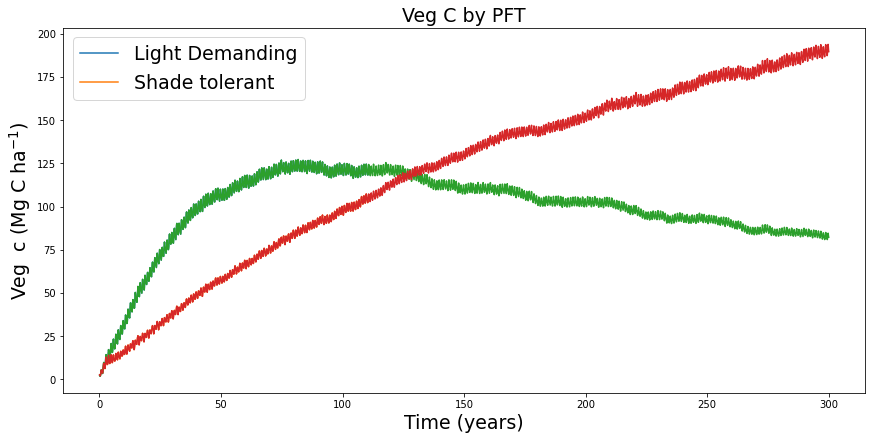

In [49]:
AGB = fates_v1.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
AGB_pf = fates_v1.FATES_VEGC_PF * 10000 * 0.001 * 2


AGB_pf_ens = fates_best.FATES_VEGC_PF * 10000 * 0.001 * 2

print(len(time))
print(AGB_pf_ens.shape)


fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(12,6), constrained_layout=True)

axs.plot(time_v1, AGB_pf.isel(fates_levpft=0),label = 'Light Demanding')  
axs.plot(time_v1, AGB_pf.isel(fates_levpft=1), label = 'Shade tolerant')      
axs.legend(prop={'size':19})

axs.set_title(r'Veg C by PFT', fontsize = 19)
axs.set_ylabel(r'Veg  c (Mg C ha$^{-1}$)', fontsize = 19)
axs.set_xlabel(r'Time (years)', fontsize = 19)    

axs.plot(time, np.squeeze(AGB_pf_ens.isel(fates_levpft=0)),label = 'Light Demanding')  
axs.plot(time, np.squeeze(AGB_pf_ens.isel(fates_levpft=1)), label = 'Shade tolerant')   

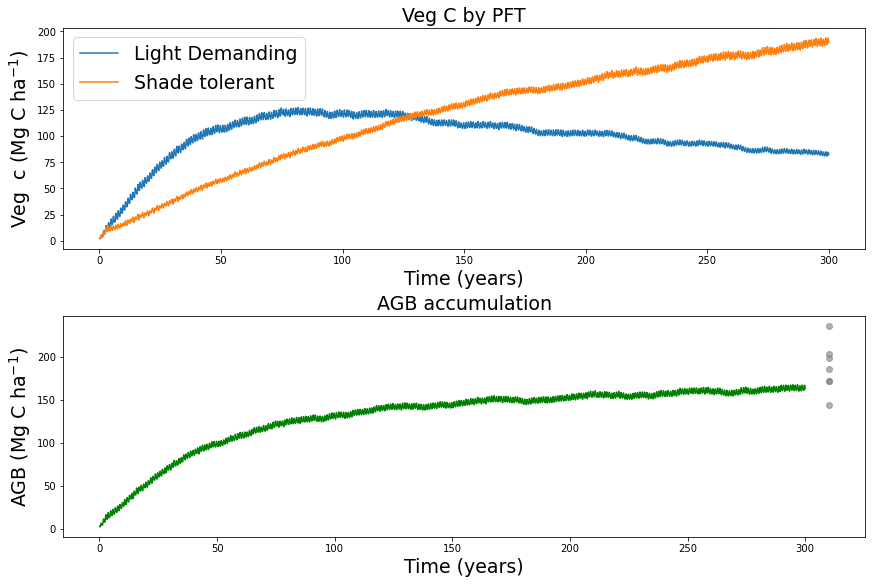

In [53]:
fig1, axs = plt.subplots(nrows=2,ncols=1, figsize=(12,8), constrained_layout=True)
axs=axs.flatten()

axs[0].plot(time, AGB_pf_ens.isel(fates_levpft=0),label = 'Light Demanding')  
axs[0].plot(time, AGB_pf_ens.isel(fates_levpft=1), label = 'Shade tolerant')      
axs[0].legend(prop={'size':19})

axs[0].set_title(r'Veg C by PFT', fontsize = 19)
axs[0].set_ylabel(r'Veg  c (Mg C ha$^{-1}$)', fontsize = 19)
axs[0].set_xlabel(r'Time (years)', fontsize = 19)    

AGB = fates_best.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')
axs[1].plot(time, AGB, color='green', label = 'FATES')    
    
axs[1].set_title(r'AGB accumulation', fontsize = 19)
axs[1].set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
axs[1].set_xlabel(r'Time (years)', fontsize = 19)    

gedi_x = [310,310,310,310,310,310,310]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16]

axs[1].scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

### Size distribution

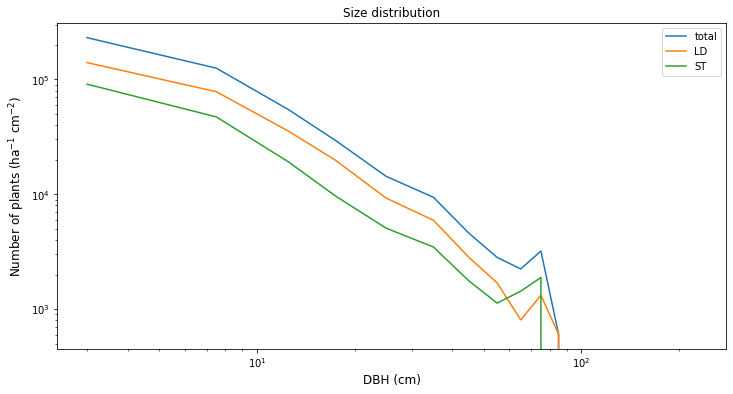

In [86]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 12)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 12)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend()
f2ax0.set_yscale('log')
f2ax0.set_xscale('log')

### Population size and AGB through time by size

(3600, 1, 15)


Text(0, 0.5, 'Cohort Size (cm)')

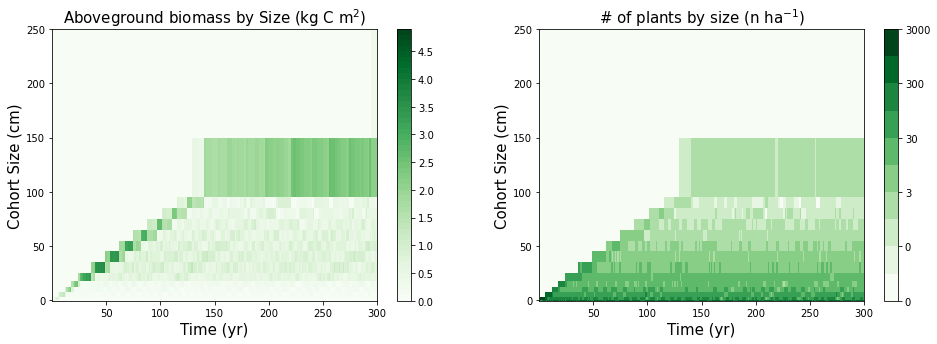

In [98]:
# population numbers as a function of cohort size
NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_VEGC_ABOVEGROUND_SZPF, fates_best)
VEGC_ABOVEGROUND_SZ  = VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levpft')
print(VEGC_ABOVEGROUND_SZ.shape)

fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax0.pcolormesh(time, cohort_size_bins, VEGC_ABOVEGROUND_SZ[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$)', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax1.pcolormesh(time, cohort_size_bins, (NPLANT_SZ)[:,0,:].transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$)', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)